IMPORT LIBRARY


In [1]:
import warnings
warnings.filterwarnings("ignore", message="A NumPy version.*")
warnings.filterwarnings("ignore", message="The figure layout.*")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from IPython.display import HTML
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from yellowbrick.classifier import ROCAUC
from matplotlib.colors import ListedColormap
sns.color_palette("Paired")
sns.set_style("whitegrid")


LOAD THE DATASET

In [2]:
df = pd.read_csv('../../dataset/diabetes.csv')
print(df.head())#Print the first 5 rows of the dataframe.

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


CHECK THE SHAPE OF DATAFRAME

In [3]:
shape = df.shape
color_hex = "#1f78b4"
colored_shape_str = "\033[38;2;{};{};{}m{}x{}\033[0m".format(
    int(color_hex[1:3], 16),
    int(color_hex[3:5], 16),
    int(color_hex[5:], 16),
    shape[0],
    shape[1]
)
print("DataFrame shape:", colored_shape_str)

DataFrame shape: 768x9


In [4]:
print(df)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

In [5]:
# Loại bỏ cột nhãn 'Outcome' để chỉ lấy các đặc trưng
features = df.drop('Outcome', axis=1)

# In ra tiêu đề bảng
print(f"{'Feature Name':<25} | {'Min':<10} | {'Max':<10} | {'Range (Max - Min)':<18}")
print("-" * 70)

# Duyệt qua từng cột và tính toán khoảng giá trị
for col in features.columns:
    col_min = features[col].min()
    col_max = features[col].max()
    col_range = col_max - col_min
    print(f"{col:<25} | {col_min:<10.2f} | {col_max:<10.2f} | {col_range:<18.2f}")


Feature Name              | Min        | Max        | Range (Max - Min) 
----------------------------------------------------------------------
Pregnancies               | 0.00       | 17.00      | 17.00             
Glucose                   | 0.00       | 199.00     | 199.00            
BloodPressure             | 0.00       | 122.00     | 122.00            
SkinThickness             | 0.00       | 99.00      | 99.00             
Insulin                   | 0.00       | 846.00     | 846.00            
BMI                       | 0.00       | 67.10      | 67.10             
DiabetesPedigreeFunction  | 0.08       | 2.42       | 2.34              
Age                       | 21.00      | 81.00      | 60.00             


In [6]:
# Calculate the number of unique values in each column
unique_value_counts = df.nunique()

for column, count in unique_value_counts.items():
    colored_count_str = "\033[38;2;{};{};{}m{}\033[0m".format(
        int(color_hex[1:3], 16),
        int(color_hex[3:5], 16),
        int(color_hex[5:], 16),
        count
    )
    print(f"{column}: {colored_count_str} unique values")

Pregnancies: 17 unique values
Glucose: 136 unique values
BloodPressure: 47 unique values
SkinThickness: 51 unique values
Insulin: 186 unique values
BMI: 248 unique values
DiabetesPedigreeFunction: 517 unique values
Age: 52 unique values
Outcome: 2 unique values


DETECT OUTLIERS


In [7]:
# Calculate the IQR for each column
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

# Define the outlier detection threshold factor
outlier_threshold_factor = 1.5

# Detect outliers using the IQR method
outliers = ((df < (Q1 - outlier_threshold_factor * IQR)) | (df > (Q3 + outlier_threshold_factor * IQR)))

# Display columns with outliers
columns_with_outliers = outliers.any()
print("\033[38;2;238;18;137m"+"Columns with outliers:"+"\033[0m")
def prGreen(skk): print("\033[92m {}\033[00m" .format(skk))
prGreen(columns_with_outliers)

Columns with outliers:
 Pregnancies                  True
Glucose                      True
BloodPressure                True
SkinThickness                True
Insulin                      True
BMI                          True
DiabetesPedigreeFunction     True
Age                          True
Outcome                     False
dtype: bool


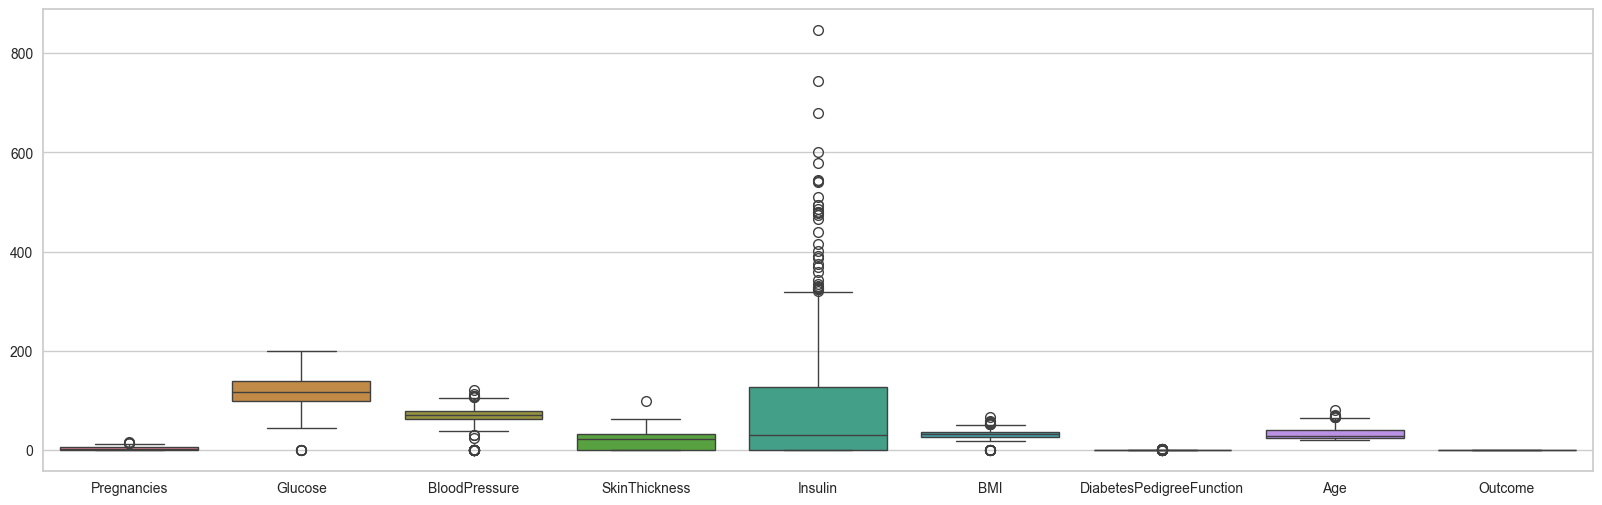

In [8]:
#outliers
plt.figure(figsize = (20, 6))
sns.boxplot(data = df, width = 0.8)
plt.show()

DATA VISUALIZATION

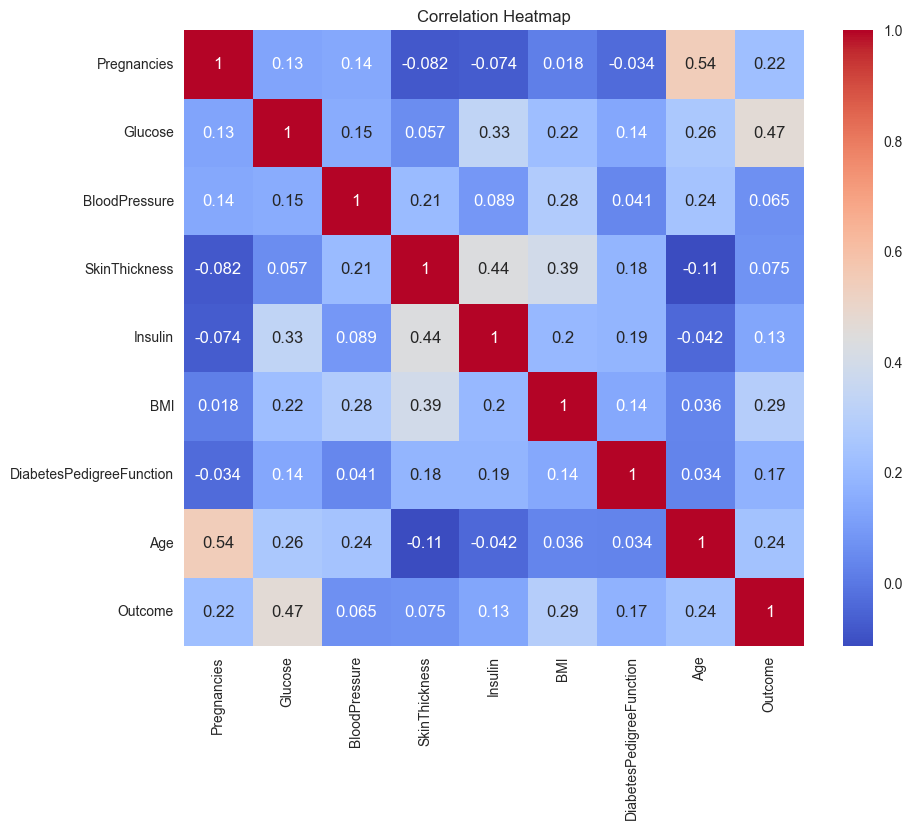

In [9]:
# Correlation heatmap
correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

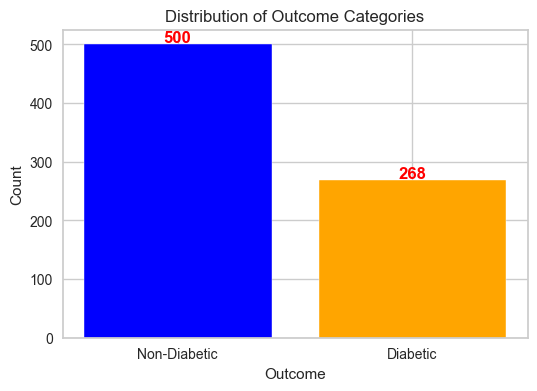

In [10]:
# Create a bar plot
outcome_counts = df['Outcome'].value_counts()
plt.figure(figsize=(6, 4))
bars = plt.bar(outcome_counts.index, outcome_counts.values, color=['blue', 'orange'])
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.title('Distribution of Outcome Categories')
plt.xticks(outcome_counts.index, ['Non-Diabetic', 'Diabetic'])

# Adding count numbers on top of the bars in red color
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + -1, round(yval, 2), ha='center', va='bottom', color='red', fontweight='bold')

plt.show()

REMOVE OUTLIERS

In [11]:
# Remove rows with outliers
df_no_outliers = df[~outliers.any(axis=1)]

# Display the modified DataFrame
color_code , reset_code = "\033[38;2;238;18;137m"  , "\033[0m"
print(color_code + "Shape of the modeified df = " +str(df_no_outliers.shape)+ reset_code)

df = df[~outliers.any(axis=1)]

Shape of the modeified df = (639, 9)


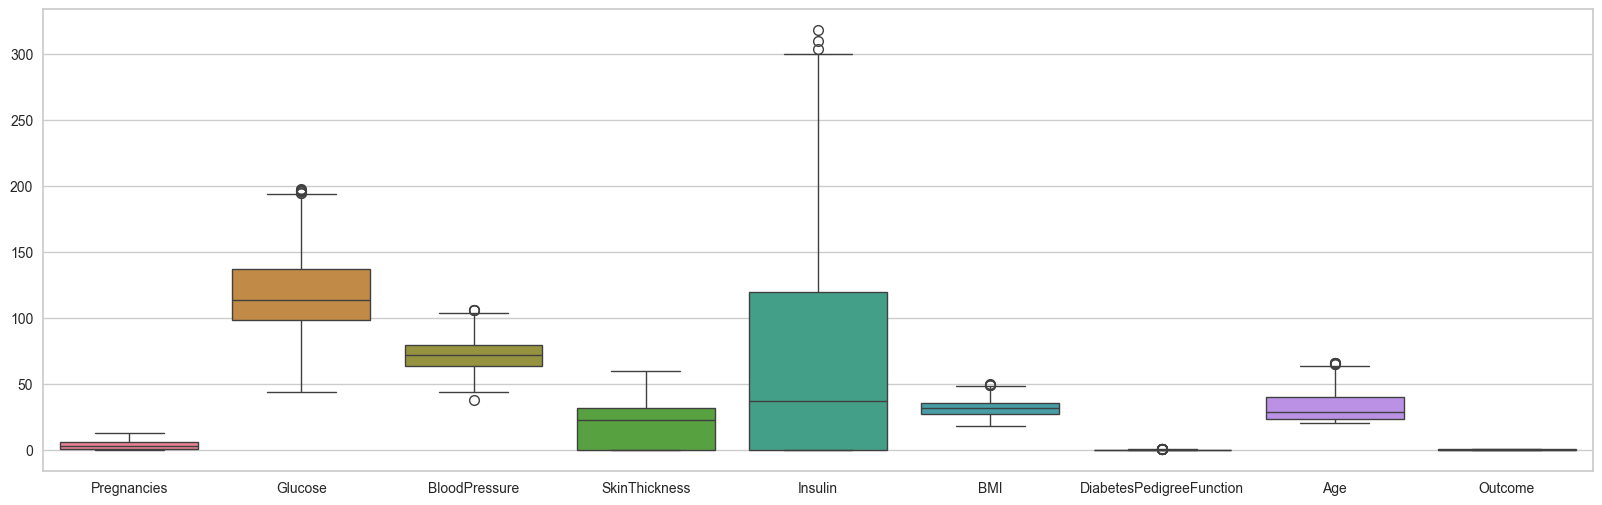

In [12]:
plt.figure(figsize = (20, 6))
sns.boxplot(data = df, width = 0.8)
plt.show()

CREATE FEATURES AND A TARGET

In [13]:
#Let's create numpy arrays for features and target
X = df.drop('Outcome',axis=1).values
y = df['Outcome'].values

SPLIT DATA INTO TRAIN + TEST

In [14]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=666)

STANDARD SCALER

In [15]:
from sklearn.preprocessing import StandardScaler

# 1. Khởi tạo bộ StandardScaler
scaler = StandardScaler()

# 2. Học tỷ lệ (fit) từ tập X_train và biến đổi (transform) nó sang chuẩn mới
X_train_scaled = scaler.fit_transform(X_train)

# 3. Chỉ biến đổi (transform) tập X_test theo tỷ lệ đã học từ tập train (Tuyệt đối không dùng fit_transform ở đây)
X_test_scaled = scaler.transform(X_test)

In [16]:
# Lấy lại danh sách tên các cột đặc trưng (bỏ cột mục tiêu 'Outcome')
feature_names = df.drop('Outcome', axis=1).columns

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_names)

# In ra 5 dòng đầu tiên của tập train đã được chuẩn hóa
print("Dữ liệu X_train sau khi Scale:")
display(X_train_scaled_df.head())

Dữ liệu X_train sau khi Scale:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.650353,-0.734221,-1.272510,0.790772,1.525049,0.293293,0.009196,0.851387
1,0.343699,1.676206,-0.753757,-1.359398,-0.830033,0.121448,-1.199862,0.672967
2,-0.882915,1.297425,-0.062088,0.008892,1.252356,-1.018976,-1.249044,-0.843603
3,-0.576262,-1.009699,0.629582,-0.447205,-0.148298,-1.206443,-0.732633,-0.843603
4,-0.269608,0.436558,0.629582,-1.359398,-0.830033,0.355782,-0.105562,0.940597


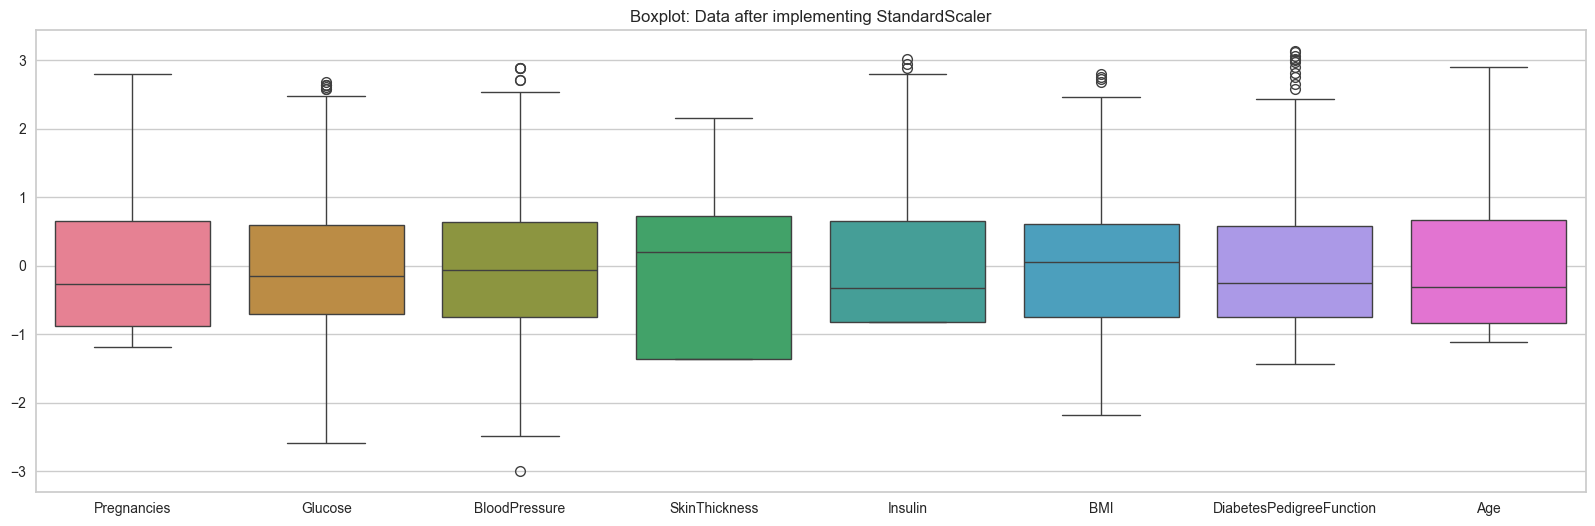

In [17]:
plt.figure(figsize=(20, 6))
sns.boxplot(data=X_train_scaled_df, width=0.8)
plt.title("Boxplot: Data after implementing StandardScaler")
plt.show()

In [18]:
# Lấy lại danh sách tên cột để in ra cho rõ ràng
feature_names = df.drop('Outcome', axis=1).columns

# In ra tiêu đề bảng
print(f"{'Feature Name':<25} | {'Min (Scaled)':<15} | {'Max (Scaled)':<15} | {'Range (Max - Min)':<18}")
print("-" * 80)

# Duyệt qua từng cột trong mảng numpy X_train_scaled
for idx, col_name in enumerate(feature_names):
    col_data = X_train_scaled[:, idx]
    col_min = col_data.min()
    col_max = col_data.max()
    col_range = col_max - col_min
    print(f"{col_name:<25} | {col_min:<15.4f} | {col_max:<15.4f} | {col_range:<18.4f}")


Feature Name              | Min (Scaled)    | Max (Scaled)    | Range (Max - Min) 
--------------------------------------------------------------------------------
Pregnancies               | -1.1896         | 2.7969          | 3.9865            
Glucose                   | -2.5937         | 2.6748          | 5.2685            
BloodPressure             | -3.0017         | 2.8775          | 5.8792            
SkinThickness             | -1.3594         | 2.1591          | 3.5185            
Insulin                   | -0.8300         | 3.0125          | 3.8425            
BMI                       | -2.1750         | 2.7929          | 4.9679            
DiabetesPedigreeFunction  | -1.4335         | 3.1282          | 4.5616            
Age                       | -1.1112         | 2.9032          | 4.0144            


CREATE KNN FROM SCRATCH

In [19]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin


class KNeighborsClassifier(BaseEstimator, ClassifierMixin):
    """
    A K-Nearest Neighbors Classifier implemented from scratch using NumPy.
    
    Parameters:
    -----------
    n_neighbors : int, default=5
        Number of neighbors to use for queries.
    metric : str, default='euclidean'
        Distance metric to use. Supported metrics: 'euclidean', 'manhattan'.
    """
    def __init__(self, n_neighbors=5, metric='euclidean'):
        self.n_neighbors = n_neighbors
        self.metric = metric
        self.X_train = None
        self.y_train = None
        self.classes_ = None

    def fit(self, X, y):
        """
        Fit the model using X as training data and y as target values.
        
        Parameters:
        -----------
        X : array-like of shape (n_samples, n_features)
            Training data.
        y : array-like of shape (n_samples,)
            Target values.
        """
        self.X_train = np.asarray(X, dtype=float)
        self.y_train = np.asarray(y)

        if not isinstance(self.n_neighbors, int) or self.n_neighbors <= 0:
            raise ValueError("n_neighbors must be a positive integer")
        if self.metric not in ('euclidean', 'manhattan'):
            raise ValueError("metric must be 'euclidean' or 'manhattan'")
        if self.X_train.ndim != 2:
            raise ValueError("X must be a 2D array-like structure")
        if len(self.X_train) != len(self.y_train):
            raise ValueError("X and y must have the same number of samples")
        if self.n_neighbors > len(self.X_train):
            raise ValueError("n_neighbors cannot be greater than the number of training samples")

        self.classes_ = np.unique(self.y_train)
        return self

    def _compute_distances(self, row):
        """Compute distances from a query row to all training samples."""
        if self.metric == 'euclidean':
            return np.sqrt(np.sum((self.X_train - row) ** 2, axis=1))
        elif self.metric == 'manhattan':
            return np.sum(np.abs(self.X_train - row), axis=1)
        else:
            raise ValueError(f"Unknown metric: {self.metric}")

    def _nearest_neighbor_labels(self, row):
        """Get the labels of the n_neighbors nearest neighbors for a single sample."""
        distances = self._compute_distances(row)
        # Argsort to find the indices of the sorted distances
        neighbor_indices = np.argsort(distances)[:self.n_neighbors]
        return self.y_train[neighbor_indices]

    def _predict_one(self, row):
        """Predict class for a single query sample."""
        neighbor_labels = self._nearest_neighbor_labels(row)
        values, counts = np.unique(neighbor_labels, return_counts=True)
        
        # Tie-breaking: choose the class with the maximum vote count.
        # If there is a tie, choose the first one (smallest label value).
        max_count = counts.max()
        tied_classes = values[counts == max_count]
        return tied_classes[0]

    def _predict_proba_one(self, row):
        """Predict class probabilities for a single query sample."""
        neighbor_labels = self._nearest_neighbor_labels(row)
        # Count occurrences of each class among the neighbors
        probs = []
        for c in self.classes_:
            probs.append(np.mean(neighbor_labels == c))
        return np.array(probs)

    def predict(self, X):
        """
        Predict class labels for samples in X.
        
        Parameters:
        -----------
        X : array-like of shape (n_samples, n_features)
            Samples to predict.
            
        Returns:
        --------
        y_pred : ndarray of shape (n_samples,)
            Class labels for each data sample.
        """
        self._check_is_fitted()
        X_arr = np.asarray(X, dtype=float)
        return np.array([self._predict_one(row) for row in X_arr])

    def predict_proba(self, X):
        """
        Predict class probabilities for samples in X.
        
        Parameters:
        -----------
        X : array-like of shape (n_samples, n_features)
            Samples to predict.
            
        Returns:
        --------
        probabilities : ndarray of shape (n_samples, n_classes)
            Class probabilities for each data sample.
        """
        self._check_is_fitted()
        X_arr = np.asarray(X, dtype=float)
        return np.array([self._predict_proba_one(row) for row in X_arr])

    def _check_is_fitted(self):
        if self.X_train is None or self.y_train is None:
            raise ValueError("This KNNClassifier instance is not fitted yet. Call 'fit' before predicting.")


TUNING - FIND THE BEST N FOR THE MODEL

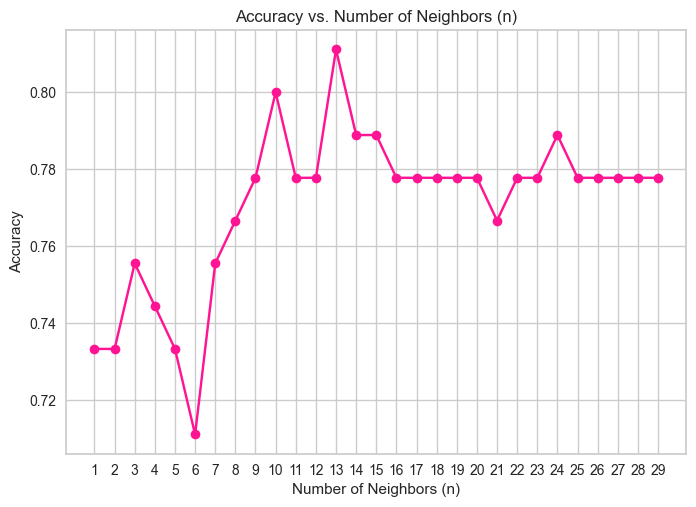

In [20]:
# Thay X_train bằng X_train_scaled để chia từ tập đã scale 
# Validation set = 20% test set old
# Train set : fit - store data
# Validation set : in the process of tuning, test the accuracy of model "pretrained" with train set

X_train_sub_scaled, X_val_scaled, y_train_sub, y_val = train_test_split(X_train_scaled, y_train, test_size=0.2, random_state=42)

n_values = list(range(1,30))
accuracies = []

for n in n_values:
    knn = KNeighborsClassifier(n_neighbors=n)
    # SỬA: Dùng X_train_sub_scaled
    knn.fit(X_train_sub_scaled, y_train_sub)
    # SỬA: Dùng X_val_scaled
    y_pred_val = knn.predict(X_val_scaled)
    accuracy = accuracy_score(y_val, y_pred_val)
    accuracies.append(accuracy)

best_n = n_values[np.argmax(accuracies)]
colored_text = f'<span style="color: #1f78b4; font-weight: bold;">Best value of n: {best_n}</span>'
display(HTML(colored_text))

plt.figure()
plt.plot(n_values, accuracies, marker='o',color = "deeppink")
plt.title("Accuracy vs. Number of Neighbors (n)")
plt.xlabel("Number of Neighbors (n)")
plt.ylabel("Accuracy")
plt.xticks(n_values)
plt.grid(True)
plt.show()

long_text = ''' <span style="color: #1f78b4;"> In the context of applying the K-Nearest Neighbors (KNN) algorithm to our dataset, a thorough evaluation of various values of n (representing the number of nearest neighbors) has been conducted. This evaluation aimed to identify the optimal value that yields the most favorable results in terms of predictive accuracy and generalization. After careful analysis and experimentation, it has been observed that the value of n equal to 13 demonstrates superior performance for our specific dataset. This choice strikes a balance between incorporating sufficient local information from neighboring data points while avoiding overfitting. Therefore, based on our evaluations, we have determined that setting n to 13 optimally aligns with the characteristics of our dataset and contributes to achieving robust and reliable predictions. </span> '''

display(HTML(long_text))

APPLY KNN ON THE TRAIN SET, AFTER THAT WE APPLY ON THE TEST SET AND SEE THE ACCURACY

In [21]:
# Create a KNN classifier with the best value of n
knn_best = KNeighborsClassifier(n_neighbors=best_n)

# fix :Train the classifier on the scaled training set
knn_best.fit(X_train_scaled, y_train)

# fix :Predict on the scaled test set
y_pred_test = knn_best.predict(X_test_scaled)

# Calculate accuracy on the test set
test_accuracy = accuracy_score(y_test, y_pred_test)

colored_text = f'<span style="color: #1f78b4; font-weight: bold;">Accuracy on test set with n =</span> {best_n} : {test_accuracy}'
long_text = ''' <span style="color: #1f78b4;"> The model has been successfully trained and evaluated on the scaled testing dataset, confirming the accuracy improvements achieved through Hyperparameter Tuning. </span> '''

display(HTML(colored_text))
display(HTML(long_text))

EVANGELION TIME

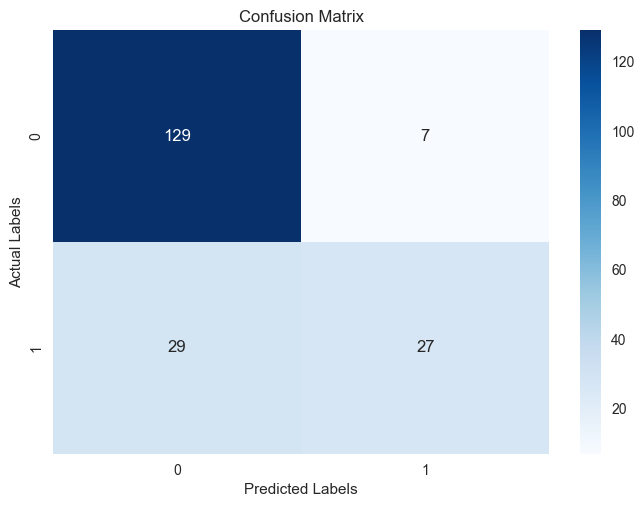

In [22]:
# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_test)

# Create a heatmap for the confusion matrix
plt.figure()
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.show()

In [23]:
prGreen(classification_report(y_test,y_pred_test,digits=4))

               precision    recall  f1-score   support

           0     0.8165    0.9485    0.8776       136
           1     0.7941    0.4821    0.6000        56

    accuracy                         0.8125       192
   macro avg     0.8053    0.7153    0.7388       192
weighted avg     0.8099    0.8125    0.7966       192



## PARTICLE SWARM OPTIMIZATION (PSO) FOR FEATURE SELECTION

To improve accuracy and reduce model complexity, we will implement Particle Swarm Optimization (PSO) to find the best subset of features.
- **Fitness function**: Accuracy on the validation set (`X_val_scaled`, `y_val`).
- **Test set**: The test set is completely hidden during the PSO feature selection to prevent data leakage and overly optimistic evaluation results.

In [24]:
from pso import BinaryPSOFeatureSelection

# Initialize the Binary PSO Feature Selector
# We use KNeighborsClassifier(n_neighbors=best_n) as the estimator
# best_n is found during hyperparameter tuning
knn_model = KNeighborsClassifier(n_neighbors=best_n)
pso_selector = BinaryPSOFeatureSelection(
    num_features=X_train_scaled.shape[1],
    estimator=knn_model,
    num_particles=15,
    max_iter=30,
    verbose=True
)

# Find the best features on the sub-train and validation sets
best_feature_mask, best_val_accuracy = pso_selector.fit(
    X_train_sub_scaled, y_train_sub, X_val_scaled, y_val
)

Iteration  1/30: Best Val Acc = 0.7556 | Selected features indices = [0, 1, 2, 4, 6]
Iteration  2/30: Best Val Acc = 0.7889 | Selected features indices = [1, 2, 6, 7]
Iteration  3/30: Best Val Acc = 0.7889 | Selected features indices = [1, 2, 6, 7]
Iteration  4/30: Best Val Acc = 0.7889 | Selected features indices = [1, 2, 6, 7]
Iteration  5/30: Best Val Acc = 0.7889 | Selected features indices = [1, 2, 6, 7]
Iteration  6/30: Best Val Acc = 0.8111 | Selected features indices = [1, 6, 7]
Iteration  7/30: Best Val Acc = 0.8111 | Selected features indices = [1, 6, 7]
Iteration  8/30: Best Val Acc = 0.8111 | Selected features indices = [1, 6, 7]
Iteration  9/30: Best Val Acc = 0.8111 | Selected features indices = [1, 6, 7]
Iteration 10/30: Best Val Acc = 0.8111 | Selected features indices = [1, 6, 7]
Iteration 11/30: Best Val Acc = 0.8111 | Selected features indices = [1, 6, 7]
Iteration 12/30: Best Val Acc = 0.8111 | Selected features indices = [1, 6, 7]
Iteration 13/30: Best Val Acc = 0.

In [25]:
# Get the names of the selected features
selected_feature_indices = np.where(best_feature_mask == 1)[0]
selected_feature_names = feature_names[selected_feature_indices].tolist()

print("Selected Feature Indices:", selected_feature_indices.tolist())
print("Selected Feature Names:", selected_feature_names)
print(f"Number of Selected Features: {len(selected_feature_names)} / {len(feature_names)}")

# Subset the scaled training and test sets
X_train_pso = X_train_scaled[:, selected_feature_indices]
X_test_pso = X_test_scaled[:, selected_feature_indices]

# Retrain the KNN classifier on the selected features using the full training set
knn_pso = KNeighborsClassifier(n_neighbors=best_n)
knn_pso.fit(X_train_pso, y_train)

# Predict on the scaled test set
y_pred_test_pso = knn_pso.predict(X_test_pso)

# Calculate final test accuracy
test_accuracy_pso = accuracy_score(y_test, y_pred_test_pso)

colored_text_pso = f'<span style="color: #1f78b4; font-weight: bold;">Accuracy on test set with PSO Feature Selection (n = {best_n}):</span> {test_accuracy_pso:.4f}'
display(HTML(colored_text_pso))

Selected Feature Indices: [1, 6, 7]
Selected Feature Names: ['Glucose', 'DiabetesPedigreeFunction', 'Age']
Number of Selected Features: 3 / 8


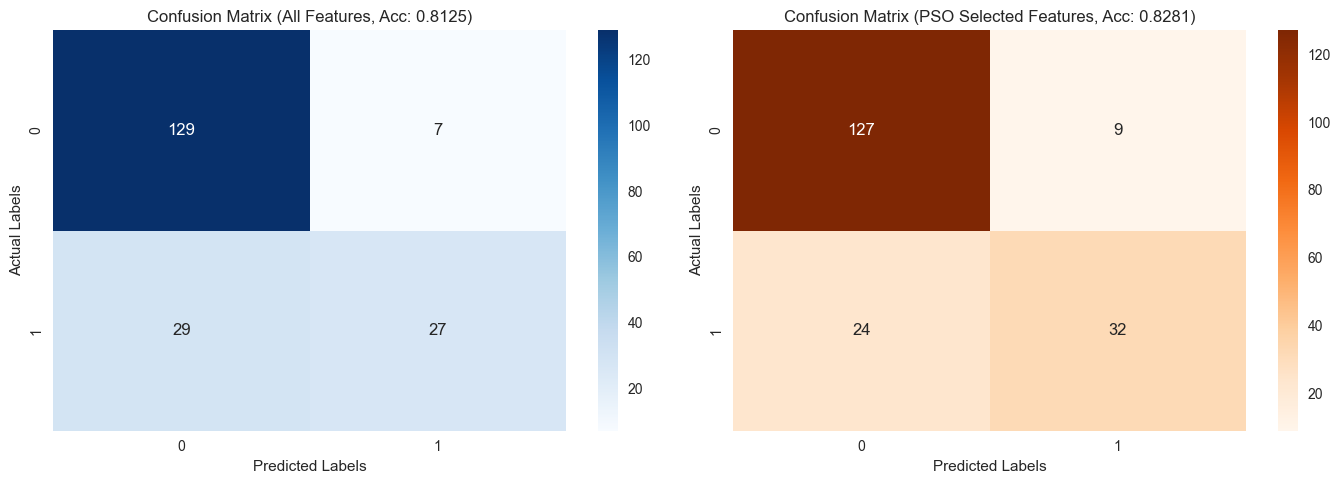

--- Classification Report for Baseline KNN (All Features) ---
               precision    recall  f1-score   support

           0     0.8165    0.9485    0.8776       136
           1     0.7941    0.4821    0.6000        56

    accuracy                         0.8125       192
   macro avg     0.8053    0.7153    0.7388       192
weighted avg     0.8099    0.8125    0.7966       192


--- Classification Report for KNN with PSO Feature Selection ---
               precision    recall  f1-score   support

           0     0.8411    0.9338    0.8850       136
           1     0.7805    0.5714    0.6598        56

    accuracy                         0.8281       192
   macro avg     0.8108    0.7526    0.7724       192
weighted avg     0.8234    0.8281    0.8193       192



In [26]:
# Create a confusion matrix for the PSO model
conf_matrix_pso = confusion_matrix(y_test, y_pred_test_pso)

# Create heatmaps to compare baseline and PSO
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f"Confusion Matrix (All Features, Acc: {test_accuracy:.4f})")
axes[0].set_xlabel("Predicted Labels")
axes[0].set_ylabel("Actual Labels")

sns.heatmap(conf_matrix_pso, annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title(f"Confusion Matrix (PSO Selected Features, Acc: {test_accuracy_pso:.4f})")
axes[1].set_xlabel("Predicted Labels")
axes[1].set_ylabel("Actual Labels")

plt.tight_layout()
plt.show()

print("--- Classification Report for Baseline KNN (All Features) ---")
prGreen(classification_report(y_test, y_pred_test, digits=4))

print("\n--- Classification Report for KNN with PSO Feature Selection ---")
prGreen(classification_report(y_test, y_pred_test_pso, digits=4))